# Credit Risk Analysis & Loan Default Prediction

**Portfolio Project | Python | Pandas | Scikit-learn | Seaborn | Matplotlib**

This project analyzes borrower and loan characteristics to identify patterns associated with loan default and evaluates machine learning approaches for predicting default risk.

### Objectives

- Assess and clean borrower and loan-level data.
- Explore relationships between borrower characteristics, loan attributes, and observed default outcomes.
- Build a transparent Logistic Regression baseline.
- Develop a Random Forest classification model.
- Compare model performance using classification and ranking metrics.
- Identify the variables that contribute most strongly to Random Forest predictions.
- Document limitations and considerations for responsible credit-risk modeling.

> **Important:** The analysis demonstrates predictive modeling techniques using a historical dataset. Model outputs should not be treated as standalone lending decisions.

In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split
from sklearn.pipeline import Pipeline
from sklearn.compose import ColumnTransformer

from sklearn.preprocessing import StandardScaler, OneHotEncoder

from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier

from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    confusion_matrix,
    classification_report,
    roc_auc_score
)

## 1. Data Loading & Initial Overview

The dataset contains borrower, loan, and credit-history attributes used to examine observed loan-default outcomes.

The initial review covers dataset dimensions, variable types, descriptive statistics, and data-quality issues requiring treatment before modeling.

In [3]:
# Load the credit-risk dataset
df = pd.read_csv(r"credit_risk_dataset.csv")

df.head()

,person_age,person_income,person_home_ownership,person_emp_length,loan_intent,loan_grade,loan_amnt,loan_int_rate,loan_status,loan_percent_income,cb_person_default_on_file,cb_person_cred_hist_length
0,22,59000,RENT,123.0,PERSONAL,D,35000,16.02,1,0.59,Y,3
1,21,9600,OWN,5.0,EDUCATION,B,1000,11.14,0,0.10,N,2
2,25,9600,MORTGAGE,1.0,MEDICAL,C,5500,12.87,1,0.57,N,3
3,23,65500,RENT,4.0,MEDICAL,C,35000,15.23,1,0.53,N,2
4,24,54400,RENT,8.0,MEDICAL,C,35000,14.27,1,0.55,Y,4


In [4]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 32581 entries, 0 to 32580
Data columns (total 12 columns):
 #   Column                      Non-Null Count  Dtype  
---  ------                      --------------  -----  
 0   person_age                  32581 non-null  int64  
 1   person_income               32581 non-null  int64  
 2   person_home_ownership       32581 non-null  object 
 3   person_emp_length           31686 non-null  float64
 4   loan_intent                 32581 non-null  object 
 5   loan_grade                  32581 non-null  object 
 6   loan_amnt                   32581 non-null  int64  
 7   loan_int_rate               29465 non-null  float64
 8   loan_status                 32581 non-null  int64  
 9   loan_percent_income         32581 non-null  float64
 10  cb_person_default_on_file   32581 non-null  object 
 11  cb_person_cred_hist_length  32581 non-null  int64  
dtypes: float64(3), int64(5), object(4)
memory usage: 3.0+ MB


In [5]:
# Inspect dataset dimensions
print(f"Rows: {df.shape[0]}")
print(f"Columns: {df.shape[1]}")

Rows: 32581
Columns: 12


In [6]:
# Review descriptive statistics
df.describe().T

,count,mean,std,min,25%,50%,75%,max
person_age,32581.0,27.734600,6.348078,20.00,23.00,26.00,30.00,144.00
person_income,32581.0,66074.848470,61983.119168,4000.00,38500.00,55000.00,79200.00,6000000.00
person_emp_length,31686.0,4.789686,4.142630,0.00,2.00,4.00,7.00,123.00
loan_amnt,32581.0,9589.371106,6322.086646,500.00,5000.00,8000.00,12200.00,35000.00
loan_int_rate,29465.0,11.011695,3.240459,5.42,7.90,10.99,13.47,23.22
loan_status,32581.0,0.218164,0.413006,0.00,0.00,0.00,0.00,1.00
loan_percent_income,32581.0,0.170203,0.106782,0.00,0.09,0.15,0.23,0.83
cb_person_cred_hist_length,32581.0,5.804211,4.055001,2.00,3.00,4.00,8.00,30.00


## 2. Data Cleaning & Preprocessing

Data quality checks were performed before modeling to identify implausible values, missing observations, and duplicate records.

The preprocessing workflow includes:

- Removing observations with implausible borrower ages or employment lengths.
- Imputing missing interest rates using the median interest rate within each loan grade.
- Imputing missing employment lengths using the overall median.
- Removing duplicate observations.
- Verifying that the resulting modeling dataset contains no remaining missing values.

In [7]:
df[df['person_age'] > 100]

,person_age,person_income,person_home_ownership,person_emp_length,loan_intent,loan_grade,loan_amnt,loan_int_rate,loan_status,loan_percent_income,cb_person_default_on_file,cb_person_cred_hist_length
81,144,250000,RENT,4.0,VENTURE,C,4800,13.57,0,0.02,N,3
183,144,200000,MORTGAGE,4.0,EDUCATION,B,6000,11.86,0,0.03,N,2
575,123,80004,RENT,2.0,EDUCATION,B,20400,10.25,0,0.25,N,3
747,123,78000,RENT,7.0,VENTURE,B,20000,NaN,0,0.26,N,4
32297,144,6000000,MORTGAGE,12.0,PERSONAL,C,5000,12.73,0,0.00,N,25


In [8]:
df[df['person_emp_length'] > 60]

,person_age,person_income,person_home_ownership,person_emp_length,loan_intent,loan_grade,loan_amnt,loan_int_rate,loan_status,loan_percent_income,cb_person_default_on_file,cb_person_cred_hist_length
0,22,59000,RENT,123.0,PERSONAL,D,35000,16.02,1,0.59,Y,3
210,21,192000,MORTGAGE,123.0,VENTURE,A,20000,6.54,0,0.10,N,4


In [9]:
df_clean = df[
    (df['person_age'] <= 100) &
    (df['person_emp_length'].isna() | (df['person_emp_length'] <= 60))
].copy()

In [10]:
print("Before cleaning:", df.shape)
print("After cleaning:", df_clean.shape)

Before cleaning: (32581, 12)
After cleaning: (32574, 12)


In [11]:
missing = df_clean.isnull().sum()
missing_percent = (missing / len(df_clean) * 100).round(2)

pd.DataFrame({
    'Missing Values': missing,
    'Missing %': missing_percent
})

,Missing Values,Missing %
person_age,0,0.00
person_income,0,0.00
person_home_ownership,0,0.00
person_emp_length,895,2.75
loan_intent,0,0.00
loan_grade,0,0.00
loan_amnt,0,0.00
loan_int_rate,3115,9.56
loan_status,0,0.00
loan_percent_income,0,0.00


In [12]:
df_clean.groupby('loan_grade')['loan_int_rate'].agg(
    ['count', 'mean', 'median']
).round(2)

,count,mean,median
loan_grade,,,
A,9773,7.33,7.49
B,9393,11.00,10.99
C,5826,13.46,13.48
D,3313,15.36,15.31
E,881,17.01,16.82
F,214,18.61,18.54
G,59,20.25,20.16


In [13]:
df_clean['loan_int_rate'] = (
    df_clean['loan_int_rate']
    .fillna(
        df_clean.groupby('loan_grade')['loan_int_rate']
        .transform('median')
    )
)

In [14]:
print("Missing loan interest rates:",
      df_clean['loan_int_rate'].isnull().sum())

Missing loan interest rates: 0


In [15]:
df_clean['person_emp_length'].describe()

count    31679.000000
mean         4.782064
std          4.034948
min          0.000000
25%          2.000000
50%          4.000000
75%          7.000000
max         41.000000
Name: person_emp_length, dtype: float64

In [16]:
print("Mean:", df_clean['person_emp_length'].mean())
print("Median:", df_clean['person_emp_length'].median())

Mean: 4.782063827772341
Median: 4.0


In [17]:
df_clean['person_emp_length'] = (
    df_clean['person_emp_length']
    .fillna(df_clean['person_emp_length'].median())
)

In [18]:
print("Remaining missing values:")
print(df_clean.isnull().sum())

print("\nFinal dataset shape:", df_clean.shape)

Remaining missing values:
person_age                    0
person_income                 0
person_home_ownership         0
person_emp_length             0
loan_intent                   0
loan_grade                    0
loan_amnt                     0
loan_int_rate                 0
loan_status                   0
loan_percent_income           0
cb_person_default_on_file     0
cb_person_cred_hist_length    0
dtype: int64

Final dataset shape: (32574, 12)


In [19]:
df_clean.duplicated().sum()

np.int64(165)

In [20]:
df_clean.drop_duplicates(inplace = True)
df_clean

,person_age,person_income,person_home_ownership,person_emp_length,loan_intent,loan_grade,loan_amnt,loan_int_rate,loan_status,loan_percent_income,cb_person_default_on_file,cb_person_cred_hist_length
1,21,9600,OWN,5.0,EDUCATION,B,1000,11.14,0,0.10,N,2
2,25,9600,MORTGAGE,1.0,MEDICAL,C,5500,12.87,1,0.57,N,3
3,23,65500,RENT,4.0,MEDICAL,C,35000,15.23,1,0.53,N,2
4,24,54400,RENT,8.0,MEDICAL,C,35000,14.27,1,0.55,Y,4
5,21,9900,OWN,2.0,VENTURE,A,2500,7.14,1,0.25,N,2
...,...,...,...,...,...,...,...,...,...,...,...,...
32576,57,53000,MORTGAGE,1.0,PERSONAL,C,5800,13.16,0,0.11,N,30
32577,54,120000,MORTGAGE,4.0,PERSONAL,A,17625,7.49,0,0.15,N,19
32578,65,76000,RENT,3.0,HOMEIMPROVEMENT,B,35000,10.99,1,0.46,N,28
32579,56,150000,MORTGAGE,5.0,PERSONAL,B,15000,11.48,0,0.10,N,26


## 3. Exploratory Data Analysis

Exploratory analysis was used to understand the distribution of loan outcomes and examine how borrower characteristics and loan attributes vary across default and non-default groups.

The analysis focuses on:

- Overall default prevalence.
- Default rates across loan grades.
- Differences in financial characteristics between default and non-default borrowers.
- Default rates across selected categorical variables.
- Correlations among numerical variables.

In [21]:
loan_dist = df_clean['loan_status'].value_counts()
loan_pct = df_clean['loan_status'].value_counts(normalize=True)*100
print("Loan Distribution:\n")
print(f"Non_default: {loan_dist[0]} ({loan_pct[0]:.2f}%)")
print(f"Default: {loan_dist[1]} ({loan_pct[1]:.2f}%)")


Loan Distribution:

Non_default: 25321 (78.13%)
Default: 7088 (21.87%)


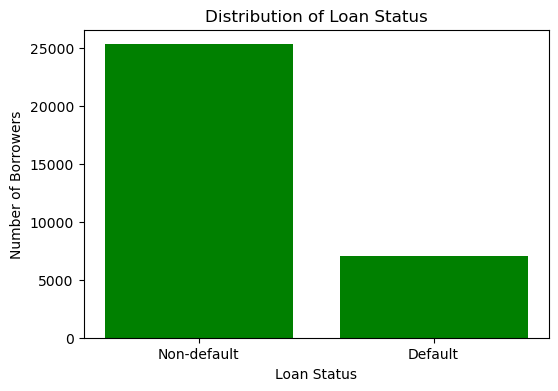

In [22]:
status_counts = df_clean['loan_status'].value_counts().sort_index()

plt.figure(figsize=(6, 4))
plt.bar(['Non-default', 'Default'], status_counts.values, color = "green")
plt.title('Distribution of Loan Status')
plt.xlabel('Loan Status')
plt.ylabel('Number of Borrowers')
plt.show()

### Loan Status Distribution

After data cleaning and duplicate removal, the modeling dataset contains **32,409 observations**. Of these, **25,321 (78.13%)** are classified as non-default and **7,088 (21.87%)** as default.

The target variable is therefore moderately imbalanced. Model evaluation should consequently consider class-specific metrics such as precision, recall, and F1-score alongside overall accuracy and ROC-AUC.

In [23]:
grade_default_rate = (
    df_clean.groupby('loan_grade')['loan_status']
    .mean()
    .sort_index()
    * 100
)

grade_default_rate.round(2)

loan_grade
A     9.96
B    16.32
C    20.76
D    59.05
E    64.49
F    70.54
G    98.44
Name: loan_status, dtype: float64

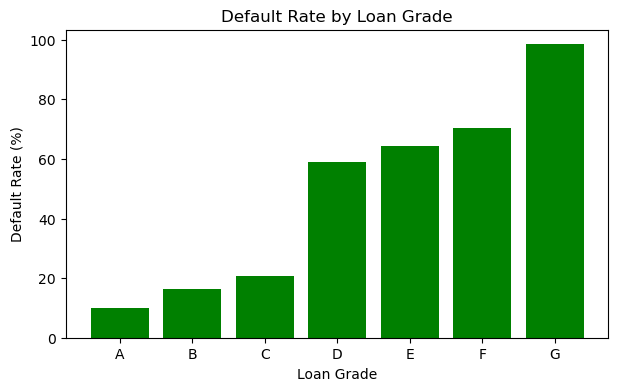

In [24]:
plt.figure(figsize=(7, 4))

plt.bar(grade_default_rate.index, grade_default_rate.values, color = "green")

plt.title('Default Rate by Loan Grade')
plt.xlabel('Loan Grade')
plt.ylabel('Default Rate (%)')

plt.show()

### Loan Grade and Default Risk

Observed default rates vary substantially across loan grades. The default rate increases from **9.96% for Grade A** to **98.44% for Grade G** in the cleaned dataset.

This strong association indicates that loan grade contains substantial predictive information about observed default outcomes and is therefore included as a feature in the subsequent modeling workflow.

These rates describe relationships within this dataset and should not be interpreted as causal effects.

In [25]:
features = [
    'person_income',
    'loan_amnt',
    'loan_int_rate',
    'loan_percent_income'
]

df_clean.groupby('loan_status')[features].mean().round(2)

,person_income,loan_amnt,loan_int_rate,loan_percent_income
loan_status,,,,
0,70597.36,9239.34,10.45,0.15
1,49093.10,10854.07,13.05,0.25


C:\Users\User\AppData\Local\Temp\ipykernel_19108\1215424102.py:15: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  plt.boxplot(data, labels=['Non-default', 'Default'], showfliers=False)


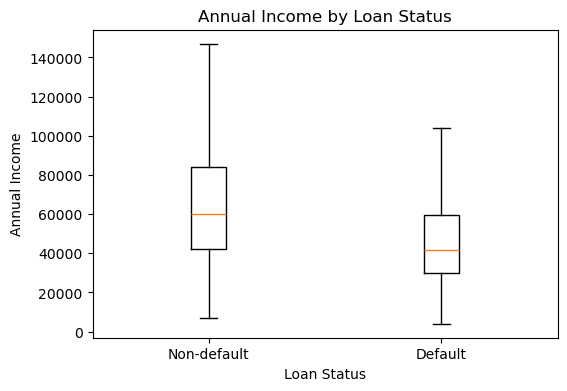

C:\Users\User\AppData\Local\Temp\ipykernel_19108\1215424102.py:15: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  plt.boxplot(data, labels=['Non-default', 'Default'], showfliers=False)


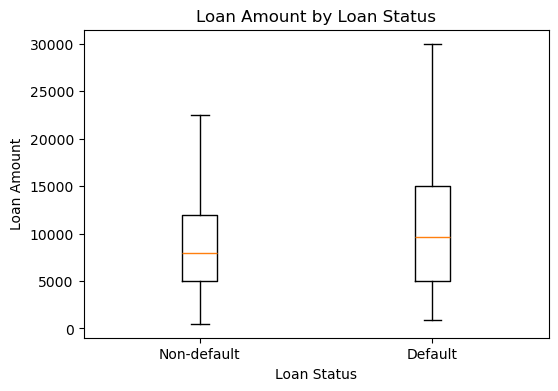

C:\Users\User\AppData\Local\Temp\ipykernel_19108\1215424102.py:15: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  plt.boxplot(data, labels=['Non-default', 'Default'], showfliers=False)


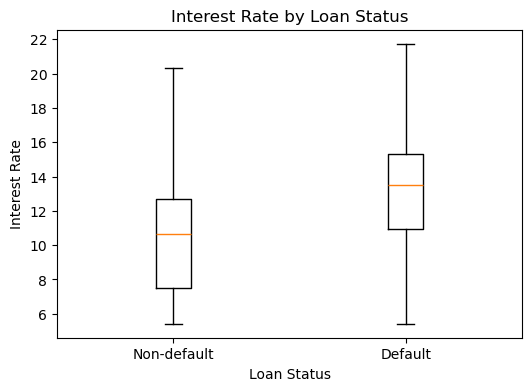

C:\Users\User\AppData\Local\Temp\ipykernel_19108\1215424102.py:15: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  plt.boxplot(data, labels=['Non-default', 'Default'], showfliers=False)


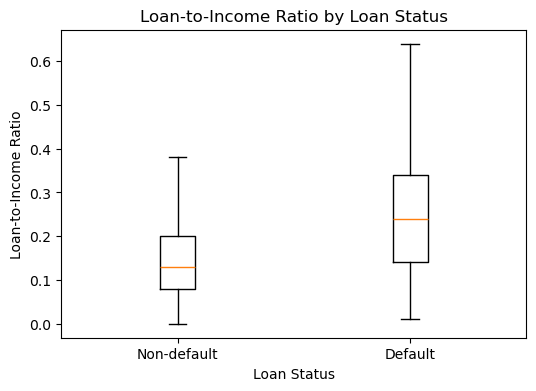

In [26]:
features = [
    ('person_income', 'Annual Income'),
    ('loan_amnt', 'Loan Amount'),
    ('loan_int_rate', 'Interest Rate'),
    ('loan_percent_income', 'Loan-to-Income Ratio')
]

for feature, title in features:
    data = [
        df_clean.loc[df_clean['loan_status'] == 0, feature],
        df_clean.loc[df_clean['loan_status'] == 1, feature]
    ]

    plt.figure(figsize=(6, 4))
    plt.boxplot(data, tick_labels=['Non-default', 'Default'], showfliers=False)
    plt.title(f'{title} by Loan Status')
    plt.xlabel('Loan Status')
    plt.ylabel(title)
    plt.show()

### Numerical Features and Default Risk

Several financial variables differ meaningfully between borrowers classified as non-default and default.

On average, defaulted borrowers in this dataset have:

- Lower annual income (**GHS 49,093** vs. **GHS 70,597**).
- Higher loan amounts (**GHS 10,854** vs. **GHS 9,239**).
- Higher interest rates (**13.05%** vs. **10.45%**).
- Higher loan-to-income ratios (**0.25** vs. **0.15**).

These differences indicate that measures of borrower financial capacity and repayment burden contain useful information for distinguishing between observed default outcomes.

In [27]:
categorical_features = [
    'person_home_ownership',
    'loan_intent',
    'cb_person_default_on_file'
]

for feature in categorical_features:
    default_rate = (
        df_clean.groupby(feature)['loan_status']
        .mean()
        .sort_values(ascending=False)
        * 100
    )

    print(f"\nDefault Rate by {feature}:")
    print(default_rate.round(2))


Default Rate by person_home_ownership:
person_home_ownership
RENT        31.61
OTHER       31.13
MORTGAGE    12.62
OWN          7.49
Name: loan_status, dtype: float64

Default Rate by loan_intent:
loan_intent
DEBTCONSOLIDATION    28.68
MEDICAL              26.76
HOMEIMPROVEMENT      26.15
PERSONAL             19.89
EDUCATION            17.26
VENTURE              14.86
Name: loan_status, dtype: float64

Default Rate by cb_person_default_on_file:
cb_person_default_on_file
Y    37.86
N    18.44
Name: loan_status, dtype: float64


### Categorical Features and Default Risk

Default rates also vary across several categorical borrower and loan characteristics.

In the cleaned dataset:

- Borrowers who rent have a default rate of **31.61%**, compared with **7.49%** among borrowers who own their homes.
- Borrowers with a previous default recorded on file have a default rate of **37.86%**, compared with **18.44%** for those without a previous default.
- Default rates range from **14.86% for venture loans** to **28.68% for debt-consolidation loans** across the observed loan purposes.

These patterns indicate that borrower housing status, prior credit history, and loan purpose provide additional predictive information for credit risk modeling. The observed differences should be interpreted as associations within the dataset rather than evidence of causation.

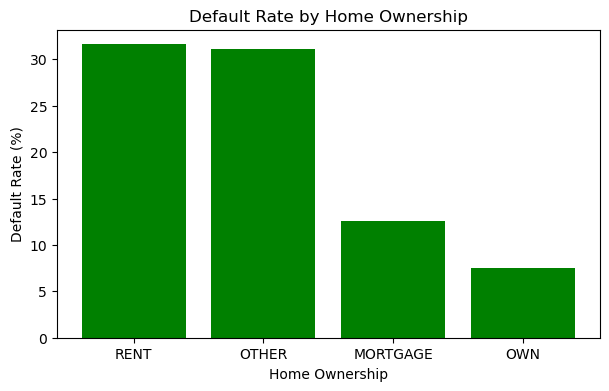

In [28]:
home_default_rate = (
    df_clean.groupby('person_home_ownership')['loan_status']
    .mean()
    .sort_values(ascending=False)
    * 100
)

plt.figure(figsize=(7, 4))
plt.bar(home_default_rate.index, home_default_rate.values, color = "green")
plt.title('Default Rate by Home Ownership')
plt.xlabel('Home Ownership')
plt.ylabel('Default Rate (%)')
plt.show()

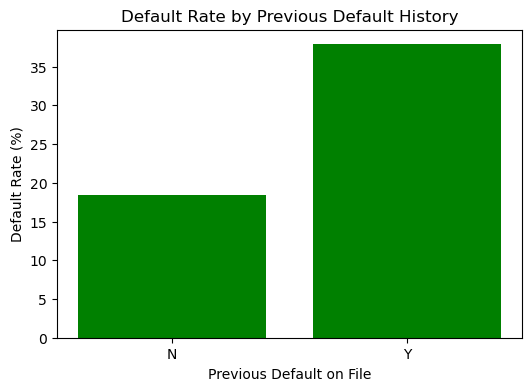

In [29]:
history_default_rate = (
    df_clean.groupby('cb_person_default_on_file')['loan_status']
    .mean()
    * 100
)

plt.figure(figsize=(6, 4))
plt.bar(history_default_rate.index, history_default_rate.values, color = "green")
plt.title('Default Rate by Previous Default History')
plt.xlabel('Previous Default on File')
plt.ylabel('Default Rate (%)')
plt.show()

### Correlation Analysis

A correlation matrix was used to examine linear relationships among numerical variables and identify potential relationships between predictors and the target variable.

The strongest positive correlations with `loan_status` are observed for:

- `loan_percent_income`: **0.38**
- `loan_int_rate`: **0.33**

`person_income` has a negative correlation of **-0.17** with `loan_status`.

Correlation measures linear association and does not establish causality. It also does not capture nonlinear relationships or interactions between variables.

In [30]:
numeric_cols = [
    'person_age',
    'person_income',
    'person_emp_length',
    'loan_amnt',
    'loan_int_rate',
    'loan_percent_income',
    'cb_person_cred_hist_length',
    'loan_status'
]

corr_matrix = df_clean[numeric_cols].corr()

corr_matrix.round(2)

,person_age,person_income,person_emp_length,loan_amnt,loan_int_rate,loan_percent_income,cb_person_cred_hist_length,loan_status
person_age,1.00,0.14,0.17,0.05,0.01,-0.04,0.88,-0.02
person_income,0.14,1.00,0.16,0.32,-0.01,-0.29,0.12,-0.17
person_emp_length,0.17,0.16,1.00,0.11,-0.05,-0.06,0.15,-0.09
loan_amnt,0.05,0.32,0.11,1.00,0.14,0.57,0.04,0.11
loan_int_rate,0.01,-0.01,-0.05,0.14,1.00,0.12,0.02,0.33
loan_percent_income,-0.04,-0.29,-0.06,0.57,0.12,1.00,-0.03,0.38
cb_person_cred_hist_length,0.88,0.12,0.15,0.04,0.02,-0.03,1.00,-0.02
loan_status,-0.02,-0.17,-0.09,0.11,0.33,0.38,-0.02,1.00


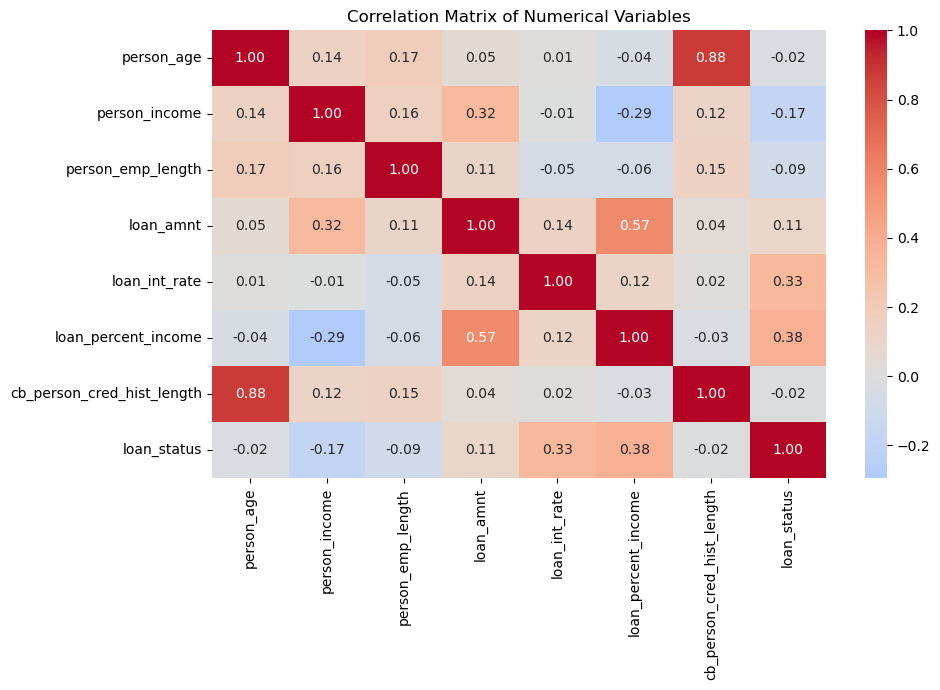

In [31]:
plt.figure(figsize=(10, 7))

sns.heatmap(
    corr_matrix,
    annot=True,
    fmt='.2f',
    cmap='coolwarm',
    center=0
)

plt.title('Correlation Matrix of Numerical Variables')
plt.tight_layout()
plt.show()

### EDA Summary

The exploratory analysis identifies several variables with meaningful associations with observed loan default.

Loan grade shows a pronounced gradient in default rates, while borrowers with higher loan-to-income ratios, higher interest rates, and lower incomes are more frequently classified as defaults. Differences are also observed across home-ownership categories, loan purposes, and previous default history.

The numerical analysis shows the strongest correlations with `loan_status` for `loan_percent_income` (**0.38**) and `loan_int_rate` (**0.33**), while `person_income` is negatively correlated with the target (**-0.17**).

Overall, the EDA suggests that borrower financial capacity, repayment burden, loan characteristics, and prior credit information can contribute useful signals for predicting default.

## 4. Machine Learning

Two supervised classification approaches are developed to predict loan default:

1. **Logistic Regression** — an interpretable linear baseline.
2. **Random Forest** — a nonlinear ensemble model capable of capturing interactions and more complex relationships.

Both models use the same preprocessing framework and are evaluated on the same stratified holdout test set.

In [32]:
X = df_clean.drop(columns='loan_status')
y = df_clean['loan_status']

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.20, random_state=42, stratify=y
)

### 4.2 Feature Preprocessing

The modeling pipeline separates numerical and categorical variables and applies transformations appropriate to each feature type.

**Numerical features**
- Standardized using `StandardScaler`.

**Categorical features**
- Encoded using one-hot encoding.
- Unknown categories are ignored during transformation to make the pipeline robust to unseen categories.

Using a unified preprocessing pipeline helps ensure that the same transformations are applied consistently during model training and prediction.

In [33]:

numeric_features = [
    'person_age',
    'person_income',
    'person_emp_length',
    'loan_amnt',
    'loan_int_rate',
    'loan_percent_income',
    'cb_person_cred_hist_length'
]

categorical_features = [
    'person_home_ownership',
    'loan_intent',
    'loan_grade',
    'cb_person_default_on_file'
]

numeric_transformer = Pipeline(
    steps=[
        ('scaler', StandardScaler())
    ]
)

categorical_transformer = Pipeline(
    steps=[
        ('onehot', OneHotEncoder(handle_unknown='ignore'))
    ]
)

preprocessor = ColumnTransformer(
    transformers=[
        ('num', numeric_transformer, numeric_features),
        ('cat', categorical_transformer, categorical_features)
    ]
)

print("Preprocessing pipeline created successfully.")

Preprocessing pipeline created successfully.


### 4.3 Logistic Regression

Logistic Regression is used as the baseline classification model because it provides a relatively interpretable framework for estimating the probability of default.

The model is trained using the preprocessed training data and evaluated using accuracy, precision, recall, F1-score, and ROC-AUC.

In [34]:

logistic_pipeline = Pipeline(
    steps=[
        ('preprocessor', preprocessor),
        ('classifier', LogisticRegression(
            max_iter=1000,
            random_state=42
        ))
    ]
)

logistic_pipeline.fit(X_train, y_train)

print("Logistic Regression training completed.")

Logistic Regression training completed.


In [35]:
logistic_pred = logistic_pipeline.predict(X_test)
logistic_prob = logistic_pipeline.predict_proba(X_test)[:, 1]

print(logistic_pred)
print(logistic_prob)

[0 0 0 ... 0 0 0]
[0.1144747  0.07633643 0.38576389 ... 0.00367595 0.11863092 0.11258831]


In [36]:
logistic_results = {
    'Accuracy': accuracy_score(y_test, logistic_pred),
    'Precision': precision_score(y_test, logistic_pred),
    'Recall': recall_score(y_test, logistic_pred),
    'F1 Score': f1_score(y_test, logistic_pred),
    'ROC-AUC': roc_auc_score(y_test, logistic_prob)
}

pd.Series(logistic_results).round(4)

Accuracy     0.8630
Precision    0.7563
Recall       0.5515
F1 Score     0.6378
ROC-AUC      0.8703
dtype: float64

In [37]:
print(classification_report(
    y_test,
    logistic_pred,
    target_names=['Non-default', 'Default']
))

              precision    recall  f1-score   support

 Non-default       0.88      0.95      0.92      5064
     Default       0.76      0.55      0.64      1418

    accuracy                           0.86      6482
   macro avg       0.82      0.75      0.78      6482
weighted avg       0.86      0.86      0.85      6482



### 4.4 Random Forest

A Random Forest classifier is trained as a nonlinear alternative to Logistic Regression.

The model uses **300 decision trees** and `class_weight='balanced'` to account for the imbalance between default and non-default observations. This approach can capture nonlinear relationships and interactions that may not be represented adequately by a linear model.

In [38]:
rf_pipeline = Pipeline(
    steps=[
        ('preprocessor', preprocessor),
        ('classifier', RandomForestClassifier(
            n_estimators=300,
            random_state=42,
            class_weight='balanced',
            n_jobs=-1
        ))
    ]
)

rf_pipeline.fit(X_train, y_train)

print("Random Forest training completed.")

Random Forest training completed.


In [39]:
rf_pred = rf_pipeline.predict(X_test)
rf_prob = rf_pipeline.predict_proba(X_test)[:, 1]

rf_results = {
    'Accuracy': accuracy_score(y_test, rf_pred),
    'Precision': precision_score(y_test, rf_pred),
    'Recall': recall_score(y_test, rf_pred),
    'F1 Score': f1_score(y_test, rf_pred),
    'ROC-AUC': roc_auc_score(y_test, rf_prob)
}

pd.Series(rf_results).round(4)

Accuracy     0.9355
Precision    0.9771
Recall       0.7221
F1 Score     0.8305
ROC-AUC      0.9359
dtype: float64

In [40]:
print(classification_report(
    y_test,
    rf_pred,
    target_names=['Non-default', 'Default']
))

              precision    recall  f1-score   support

 Non-default       0.93      1.00      0.96      5064
     Default       0.98      0.72      0.83      1418

    accuracy                           0.94      6482
   macro avg       0.95      0.86      0.90      6482
weighted avg       0.94      0.94      0.93      6482



### 4.5 Model Performance Comparison

The two models are evaluated on the same held-out test set using accuracy, precision, recall, F1-score, and ROC-AUC.

The comparison provides both an overall view of classification performance and a class-specific view of how effectively the models identify default cases.

In [41]:
model_comparison = pd.DataFrame({
    'Logistic Regression': logistic_results,
    'Random Forest': rf_results
}).T

model_comparison.round(4)

,Accuracy,Precision,Recall,F1 Score,ROC-AUC
Logistic Regression,0.8630,0.7563,0.5515,0.6378,0.8703
Random Forest,0.9355,0.9771,0.7221,0.8305,0.9359


### 4.6 Confusion Matrix

Confusion matrices provide a class-level breakdown of correct and incorrect predictions.

For credit risk applications, the false-negative count is particularly relevant because it represents borrowers who actually defaulted but were predicted as non-default. Reviewing the confusion matrices therefore provides additional context beyond aggregate performance metrics.

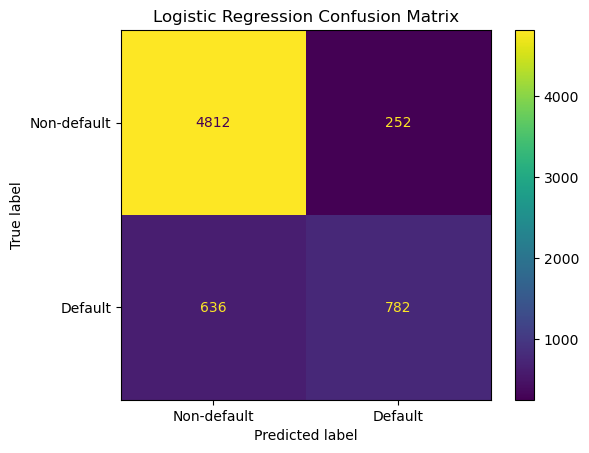

In [42]:
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay

cm_log = confusion_matrix(y_test, logistic_pred)

disp = ConfusionMatrixDisplay(
    confusion_matrix=cm_log,
    display_tick_labels=['Non-default', 'Default']
)

disp.plot()
plt.title('Logistic Regression Confusion Matrix')
plt.show()

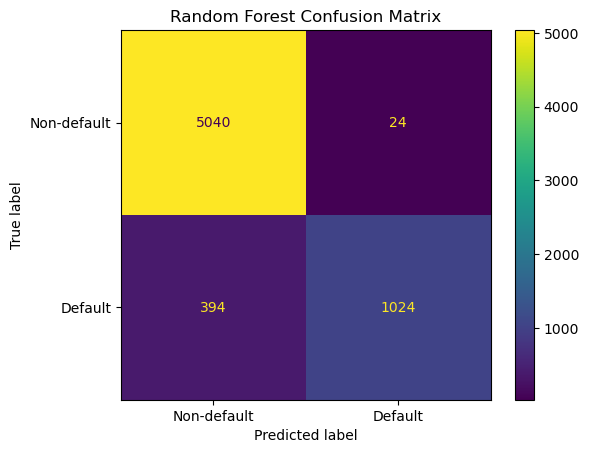

In [43]:
cm_rf = confusion_matrix(y_test, rf_pred)

disp = ConfusionMatrixDisplay(
    confusion_matrix=cm_rf,
    display_tick_labels=['Non-default', 'Default']
)

disp.plot()
plt.title('Random Forest Confusion Matrix')
plt.show()

## 5. Model Interpretation

### 5.1 Random Forest Feature Importance

Random Forest feature importance is used to identify the variables that contribute most strongly to the model's predictive decisions.

The analysis indicates which borrower and loan characteristics are most useful to the fitted model for distinguishing default from non-default observations. These importance values represent predictive contribution within the model and should **not** be interpreted as causal effects.

In [47]:
feature_names = rf_pipeline.named_steps['preprocessor'].get_feature_names_out()

feature_importance = pd.DataFrame({
    'Feature': feature_names,
    'Importance': rf_pipeline.named_steps['classifier'].feature_importances_
})

feature_importance = feature_importance.sort_values(
    'Importance',
    ascending=False
)

feature_importance.head(15)

,Feature,Importance
5,num__loan_percent_income,0.202678
1,num__person_income,0.157440
4,num__loan_int_rate,0.142915
3,num__loan_amnt,0.079453
2,num__person_emp_length,0.055161
0,num__person_age,0.048789
20,cat__loan_grade_D,0.048358
10,cat__person_home_ownership_RENT,0.039764
6,num__cb_person_cred_hist_length,0.038949
7,cat__person_home_ownership_MORTGAGE,0.020480


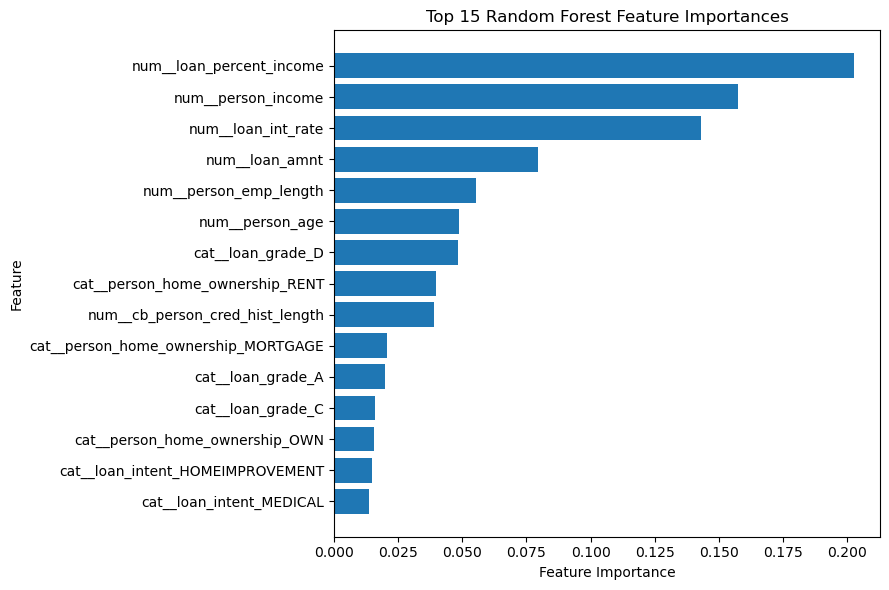

In [48]:
top_features = feature_importance.head(15).sort_values('Importance')

plt.figure(figsize=(9, 6))
plt.barh(top_features['Feature'], top_features['Importance'])

plt.xlabel('Feature Importance')
plt.ylabel('Feature')
plt.title('Top 15 Random Forest Feature Importances')

plt.tight_layout()
plt.show()

## 6. Results and Interpretation

### 6.1 Model Comparison

The executed model evaluation shows stronger predictive performance for Random Forest across the reported metrics.

| Metric | Logistic Regression | Random Forest |
|---|---:|---:|
| Accuracy | 0.8630 | 0.9355 |
| Precision | 0.7563 | 0.9771 |
| Recall | 0.5515 | 0.7221 |
| F1 Score | 0.6378 | 0.8305 |
| ROC-AUC | 0.8703 | 0.9359 |

For the default class specifically, Random Forest achieves a recall of **0.7221**, compared with **0.5515** for Logistic Regression. Its default-class F1 score is **0.8305**, compared with **0.6378** for Logistic Regression.

These results indicate that, within this test set, the Random Forest captures predictive patterns that the linear baseline does not capture as effectively.

### 6.2 Key Predictive Factors

The Random Forest feature-importance analysis identifies the following variables among the most influential predictors:

1. `loan_percent_income`
2. `person_income`
3. `loan_int_rate`
4. `loan_amnt`
5. `person_emp_length`
6. `person_age`
7. Selected loan-grade and home-ownership indicators

The results suggest that repayment burden, borrower income, pricing, and loan size contain substantial predictive information in the fitted model.

Feature importance measures predictive contribution within the model; it does not establish that changing a variable would directly cause a change in default probability.

### 6.3 Credit Risk Interpretation

The EDA and model results provide complementary perspectives on credit risk.

The descriptive analysis shows pronounced differences in default rates across loan grades and borrower characteristics, while the Random Forest model identifies loan-to-income ratio, income, interest rate, and loan amount as particularly important predictive features.

Together, the findings support the use of borrower financial capacity, repayment burden, loan characteristics, and prior credit information as inputs for further credit-risk analysis. Any operational lending application would require additional validation, governance, and fairness assessment before deployment.

## 7. Conclusion

This project developed an end-to-end credit risk analysis and loan-default prediction workflow using exploratory analysis and supervised machine learning.

After cleaning the original dataset, the final modeling dataset contained **32,409 observations**. Exploratory analysis identified meaningful differences in default rates across loan grades, home-ownership categories, loan purposes, and previous default history.

Two classification models were evaluated:

- **Logistic Regression:** ROC-AUC of **0.8703** and default-class F1 score of **0.6378**.
- **Random Forest:** ROC-AUC of **0.9359** and default-class F1 score of **0.8305**.

Within the test set, Random Forest produced stronger predictive metrics, while Logistic Regression provided a more straightforward baseline for interpretation.

The feature-importance analysis identified `loan_percent_income`, `person_income`, `loan_int_rate`, and `loan_amnt` as prominent predictive variables.

These findings demonstrate how statistical modeling and machine learning can be combined to understand borrower risk patterns and build predictive credit-risk models. The results should be treated as an analytical benchmark rather than a production lending decision framework.

## 8. Limitations & Future Work

Several limitations should be considered when interpreting the results.

### Dataset and validation
The analysis uses a single dataset and a single stratified holdout test set. External validation and time-based validation would provide stronger evidence of how the model performs on new borrower populations and future observations.

### Feature coverage
The dataset contains a limited set of borrower and loan attributes. Additional information such as detailed repayment history, debt obligations, credit utilization, macroeconomic indicators, and account-level behavioral data could provide additional predictive signal.

### Model interpretability
Random Forest provides strong predictive performance but is less directly interpretable than Logistic Regression. SHAP-based explanations and partial-dependence analysis could be explored to improve model interpretability.

### Fairness and responsible use
Credit-risk models can affect access to financial services. Future work should assess model performance across relevant borrower groups, investigate potential sources of bias, and incorporate appropriate governance and explainability controls.

### Production readiness
Before operational use, the model would require independent validation, probability calibration, threshold analysis, monitoring for data and model drift, and a documented model-risk management process.

## 9. Project Summary

This project developed an end-to-end machine learning workflow for analyzing and predicting loan default.

**Key results**

- **32,409** observations remained after data-quality filtering and duplicate removal.
- **21.87%** of observations were classified as defaults.
- Default rates varied substantially across loan grades, with observed rates ranging from **9.96% for Grade A** to **98.44% for Grade G**.
- Logistic Regression achieved **0.8703 ROC-AUC** and **0.6378 default-class F1**.
- Random Forest achieved **0.9359 ROC-AUC** and **0.8305 default-class F1**.
- Random Forest default recall was **0.7221**, compared with **0.5515** for Logistic Regression.
- `loan_percent_income`, `person_income`, `loan_int_rate`, and `loan_amnt` were among the most influential Random Forest features.

**Overall takeaway:** the analysis demonstrates how exploratory credit-risk analysis and machine learning can be combined to identify patterns associated with loan default and evaluate alternative predictive approaches.